# Quickstart: complete stellar stream analysis pipeline

This notebook walks through the full pipeline in one place:

1. **Stream injection** — place a mock stream on realistic survey data
2. **Background generation** — generate a realistic field-star and galaxy background
3. **Match filter** — select stars whose color–magnitude position is consistent with the stream's stellar population
4. **CMD visualisation** — visualise color magnitude distribution of stream and
   background objects
5. **2-D sky maps** — visualise the stream and show the depth variation across the field

> **Companion tutorials**
> - Full injection walkthrough: [`tutorial_inject_stream.ipynb`](tutorial_inject_stream.ipynb)
> - Isochrone / data-mock generation: [`tutorial_generate_datamocks.ipynb`](tutorial_generate_datamocks.ipynb)

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from matplotlib.path import Path

import astropy.coordinates as coord
import astropy.units as u
import gala.coordinates as gc

from streamobs.surveys import Survey
from streamobs.model import StreamModel
from streamobs.observed import StreamInjector
from streamobs.background import Background
from streamobs.match_filter import build_match_filter, is_in_match_filter
from streamobs.plotting import plot_healpix_counts

## Step 1 — Survey and great-circle frame

We load the LSST yr1 survey and define a great-circle frame that spans
`Dec = -30° → -60°` at `RA = 60°`. This object is then used to find (ra,dec)
coordinates for the stream and the background.

In [2]:
survey = Survey.load("lsst", release="yr1")

end1 = coord.SkyCoord(ra=60.0 * u.deg, dec=-30.0 * u.deg, frame="icrs")
end2 = coord.SkyCoord(ra=60.0 * u.deg, dec=-60.0 * u.deg, frame="icrs")
gc_frame = gc.GreatCircleICRSFrame.from_endpoints(end1, end2)

Loading survey data for 'lsst_yr1'...
  Loading config from: lsst_yr1.yaml

LOADING SURVEY DATA FILES
Survey data directory: /sps/lsst/users/mpelissi/packages/streamobs/streamobs/../data/surveys/lsst_yr1

Fallback directory for shared data files: /sps/lsst/users/mpelissi/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, u, y, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ⚠ Warning: 'maglim_map_i' not specified in config (skipping i-band)
  ✓ Success for r-band magnitude limit
  ⚠ Warning: 'maglim_map_u' not specified in config (skipping u-band)
  ⚠ Warning: 'maglim_map_y' not specified in config (skipping y-band)
  ⚠ Warning: 'maglim_map_z' not specified in config (skipping z-band)

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: lsst_stellar_efficiency_cutr.csv
    ✓ Success
  Loading Detection efficiency function...
    File: lsst_stellar_efficiency_cut

## Step 2 — Inject a stream

We create a simple mock stream using `StreamModel` and inject it into
the LSST yr1 survey at the great-circle frame defined above.

> **Tip**: replace `stream_raw` below with your own simulation output
> (any `pd.DataFrame` with `phi1`, `phi2` columns, and optionally
> `lsst_g_true` / `lsst_r_true` if you already have magnitudes).
> See [`tutorial_inject_stream.ipynb`](tutorial_inject_stream.ipynb)
> for a detailed description of all injection options.

In [3]:
stream_config = {
    "density": {"type": "Uniform", "xmin": -18.0, "xmax": 18.0},
    "track": {
        "center": {"type": "Constant", "value": 0.0},
        "spread": {"type": "Constant", "value": 0.3},
        "sampler": "Gaussian",
    },
    "isochrone": {
        "name": "Marigo2017",
        "survey": "lsst",
        "age": 12.0,  # Gyr
        "z": 0.0006,  # metallicity
        "band_1": "g",
        "band_2": "r",
        "band_1_detection": True,
    },
    "distance_modulus": {
        "center": {"type": "Constant", "value": 16.8},
        "spread": {"type": "Constant", "value": 0.0},
    },
}

# Generate the stream model
model = StreamModel(stream_config)
stream_raw = model.sample(100000, seed=42)

In [4]:
# Inject the stream into the survey
injector = StreamInjector(survey=survey)
stream = injector.inject(
    stream_raw, gc_frame=gc_frame, seed=42, perfect_galstarsep=True
)

# Select only the stars that are observed in the survey
stream_detected = stream[stream["lsst_yr1_flag_observed"]].copy()
print(f"Detected stream stars: {len(stream_detected)} / {len(stream)}")

/sps/lsst/users/mpelissi/envs/env_miniconda_py13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Applying dust correction for r-band on observed magnitudes.
Applying dust correction for g-band on observed magnitudes.
Applying detection cut on g-band with SNR >= 5.0
Detected stream stars: 10499 / 100000


/sps/lsst/users/mpelissi/envs/env_miniconda_py13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Step 3 — Generate background

The `Background` class with `method='light'` samples from precomputed
CMD grids, so it is fast even for large fields. It reads the local
magnitude limit at each sky position and draws the appropriate number
of stars and galaxies. It includes survey selection effects, errors, and
fluctuations due to survey depth variation. This light version needs ressources
that are automatically downloaded when installing the package 
```bash
python bin/download_data.py
```
You can also decide to inject your own background model instead of using the
light method (see [full documentation](https://lsstdesc.github.io/streamobs/)).

In [5]:
# Generate both stars and galaxies in the background catalog, using the light method
bg_gen = Background(survey, source_type="both", method="light")

# generate the background catalog in the same region of the sky as the stream
# The output catalog contains observed background objects
bg_catalog, bg_meta = bg_gen.generate(
    phi1_limits=(-20, 20), phi2_limits=(-10, 10), gc_frame=gc_frame, seed=42
)
print(f"Background objects: {len(bg_catalog)}")
print(f"Columns: {list(bg_catalog.columns)}")

/sps/lsst/users/mpelissi/packages/streamobs/streamobs/background/background.py:158: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


Background objects: 12497466
Columns: ['ra', 'dec', 'phi1', 'phi2', 'lsst_yr1_r_obs', 'lsst_yr1_g_obs', 'source_type']


## Step 4 — Apply the match filter

The match filter selects stars whose (g−r, g) position is consistent
with the stream's isochrone at the given distance, accounting for
photometric errors and a small distance spread.

In [6]:
DISTANCE_MODULUS = stream_config["distance_modulus"]["center"]["value"]
AGE = stream_config["isochrone"]["age"]
METALLICITY = stream_config["isochrone"]["z"]

# Creating match filter shape in color-magnitude space
polygon_vertices = build_match_filter(
    distance_modulus=DISTANCE_MODULUS,
    age=AGE,
    metallicity=METALLICITY,
    survey="lsst",
)

# Selecting stars in the stream and background catalogs that are inside the match filter polygon
stream_in_mf = is_in_match_filter(
    stream_detected["lsst_yr1_g_obs"],
    stream_detected["lsst_yr1_r_obs"],
    polygon_vertices=polygon_vertices,
)
print(
    f"Stream selected by match filter: {stream_in_mf.sum()} / {len(stream_detected)} "
    f"({stream_in_mf.mean()*100:.1f}%)"
)

bg_in_mf = is_in_match_filter(
    bg_catalog["lsst_yr1_g_obs"],
    bg_catalog["lsst_yr1_r_obs"],
    polygon_vertices=polygon_vertices,
)
print(
    f"Background selected: {bg_in_mf.sum()} / {len(bg_catalog)} "
    f"({bg_in_mf.mean()*100:.1f}%)"
)

Stream selected by match filter: 9364 / 10499 (89.2%)
Background selected: 1187213 / 12497466 (9.5%)


In [7]:
# Combine the stream and background catalogs into a single DataFrame
combined = pd.concat(
    [
        stream_detected[stream_in_mf],
        bg_catalog[bg_in_mf],
    ],
    ignore_index=True,
)

## Step 5 — Color–magnitude diagrams

Left: the injected stream stars (detected) with the match filter polygon.
Right: stream + background together, to show how the filter isolates
the stream's stellar locus from the bulk of the background.

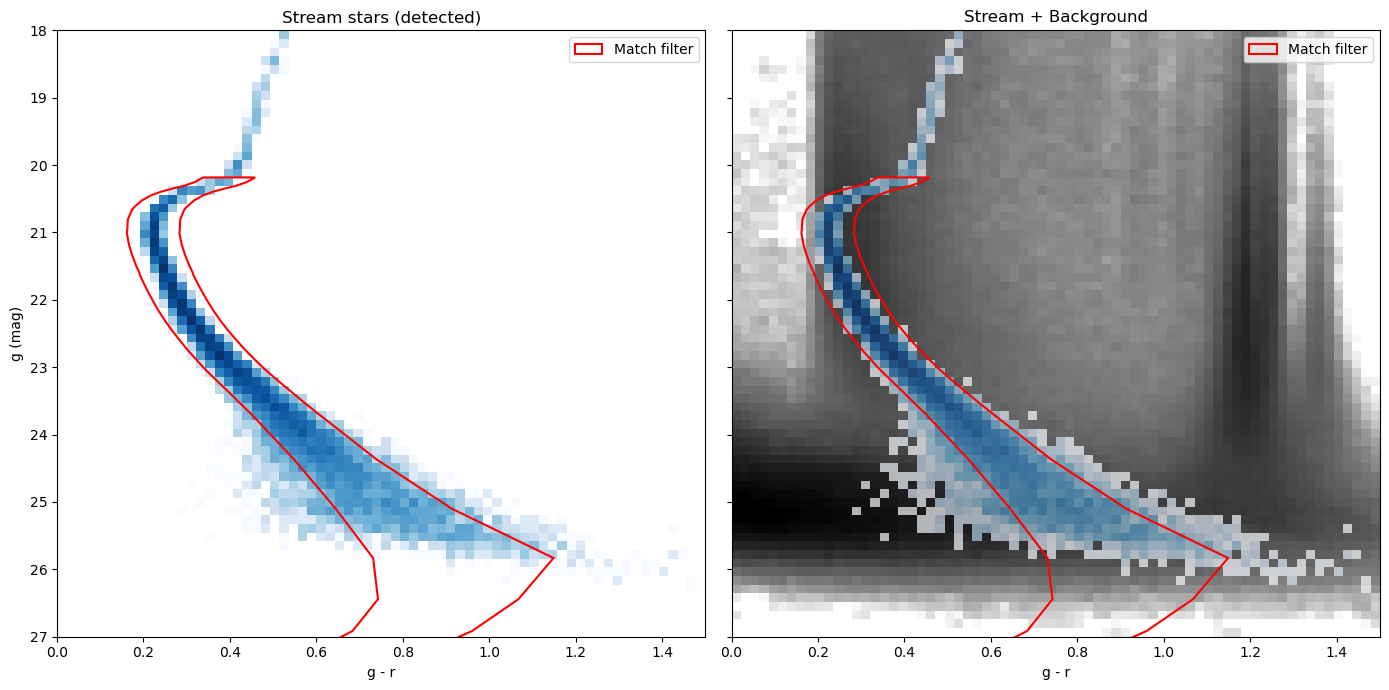

In [8]:
COLOR_RANGE = (-0, 1.5)
MAG_RANGE = (18, 27)
N_BINS = 70

g_str = stream_detected["lsst_yr1_g_obs"]
r_str = stream_detected["lsst_yr1_r_obs"]
g_bg = bg_catalog["lsst_yr1_g_obs"]
r_bg = bg_catalog["lsst_yr1_r_obs"]

mf_patch_kw = dict(
    facecolor="none", edgecolor="red", linewidth=1.5, label="Match filter"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

# --- Left: stream only ---
axes[0].hist2d(
    g_str - r_str,
    g_str,
    bins=N_BINS,
    range=[COLOR_RANGE, MAG_RANGE],
    norm=LogNorm(),
    cmap="Blues",
)
axes[0].add_patch(mpatches.PathPatch(Path(polygon_vertices), **mf_patch_kw))
axes[0].set_xlim(*COLOR_RANGE)
axes[0].set_ylim(MAG_RANGE[1], MAG_RANGE[0])
axes[0].set_xlabel("g - r")
axes[0].set_ylabel("g (mag)")
axes[0].set_title("Stream stars (detected)")
axes[0].legend()

# --- Right: stream + background ---
axes[1].hist2d(
    g_bg - r_bg,
    g_bg,
    bins=N_BINS,
    range=[COLOR_RANGE, MAG_RANGE],
    norm=LogNorm(),
    cmap="Greys",
)
axes[1].hist2d(
    g_str - r_str,
    g_str,
    bins=N_BINS,
    range=[COLOR_RANGE, MAG_RANGE],
    norm=LogNorm(),
    cmap="Blues",
    alpha=0.7,
)
axes[1].add_patch(mpatches.PathPatch(Path(polygon_vertices), **mf_patch_kw))
axes[1].set_xlim(*COLOR_RANGE)
axes[1].set_xlabel("g - r")
axes[1].set_title("Stream + Background")
axes[1].legend()

for a in axes:
    a.set_ylim(MAG_RANGE[1], MAG_RANGE[0])  # Invert y axis

plt.tight_layout()
plt.show()

## Step 6 — 2-D sky maps

The stream is placed along the great-circle frame defined in Step 1.  The
background star counts per HEALPix pixel reflect the actual LSST depth at
each sky position — note how the density changes along the Dec gradient,
which runs from `+20°` (phi1 ≈ −20°) to `−20°` (phi1 ≈ +20°) in this frame.
This spatial depth variation is automatically taken into account by the
background generator.

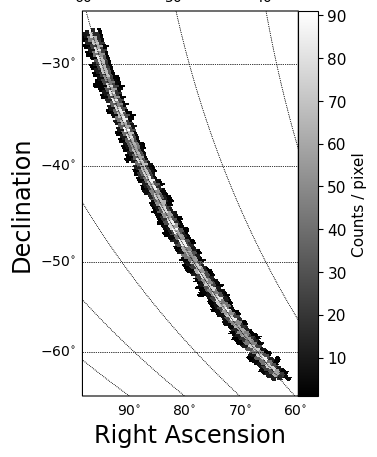

In [9]:
plot_healpix_counts(
    stream_detected["ra"],
    stream_detected["dec"],
    nside=128,
    title="Stream stars (detected)",
    cmap="grey",
)
plt.show()

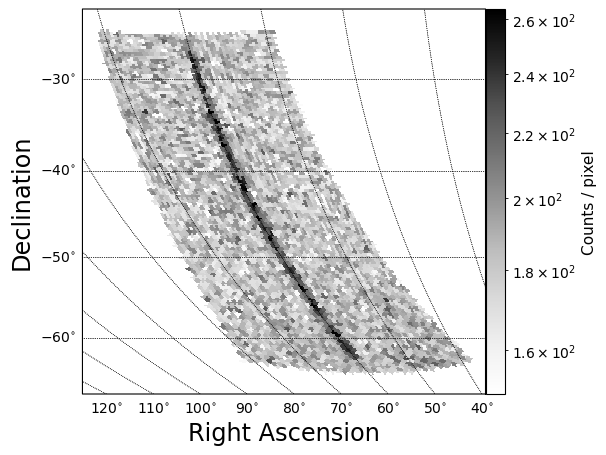

In [10]:
gals_cut = (
    combined["lsst_yr1_g_obs"] < 25.0
)  # Remove some galaxies and inhomogeneities imprinted by the survey depth variations
plot_healpix_counts(
    combined[gals_cut]["ra"],
    combined[gals_cut]["dec"],
    nside=128,
    title="Stream + Background (after match filter)",
    vmin=150,
    vmax=None,
    cmap="Greys",
    norm="log",
)
plt.show()

## Conclusion

In a few commands we went from a mock stellar stream to a realistic observational
picture: realistic survey selection, variable survey depth, realistic photometric noise, and a match filter
that boosts the stream signal relative to the background. This pipeline can then
easily be used to train stream detection algorithms and more realistic stream analyses on injected simulations.


You can find more information in the [full documentation](https://lsstdesc.github.io/streamobs/).